<img src="assets/DemoSlidesForExport_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/DemoSlidesForExport_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_2.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_3.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>
</div>

In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from IPython.display import Markdown, display

import cstar_forge
import roms_tools as rt

env = cstar_forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"Execution timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 25.4.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


Execution timestamp: 2026-05-13 16:26:38


<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [2]:
# Grid parameters ------------------------------------------------------------------
grid_name = "Gulf_of_Alaska"
grid_settings = dict[str, float](
    # nx=208,              # X-direction grid cells (xi)
    # ny=192,              # Y-direction grid cells (eta)
    nx=320,              # X-direction grid cells (xi)
    ny=560,              # Y-direction grid cells (eta)
    size_x=1460,         # km (longitude direction at ~49N)
    size_y=2350,         # km (latitude direction)
    center_lon=-139.5,   
    center_lat=53,
    rot=41,              # rotation of grid (degrees)
    N=10,                # number of vertical levels
    #N=50,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
    #close_narrow_channels=True,
)
boundaries = {
        "south": True,
        "east": False,
        "north": True,
        "west": True, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; margin: 0;">
Next we define a test model, using a pre-defined ROMS-MARBL model specification (a <b>model_spec</b>, which contains settings to enable ROMS-MARBL features and compilation to match your inputs and environment), and start and end dates.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These changeable options are passed to the CstarSpecBuilder() object, which will find and generate the <b>forcing data</b>, and <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>

CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_grid.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_initial_conditions.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_surface-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_surface-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_boundary-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_boundary-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_

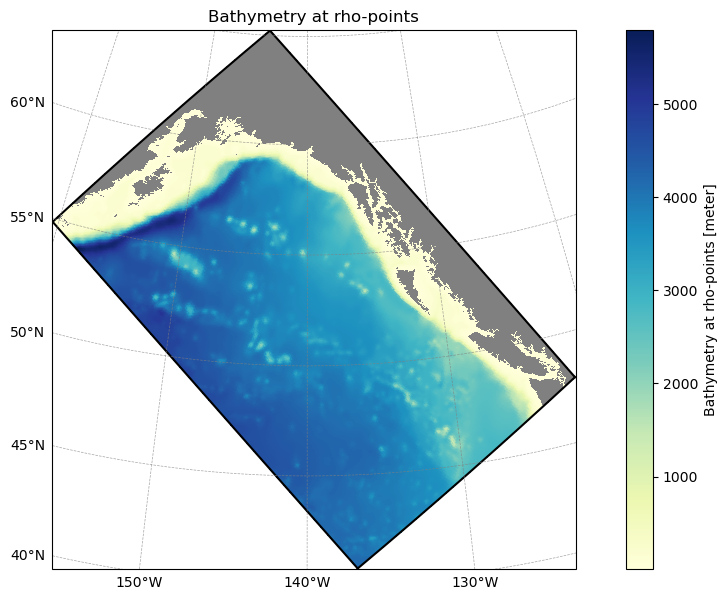

In [ ]:
#Change to roms-tools grid gen, for plotting

# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 5)

partitioning = {
    "n_procs_x": 2, # number of partitions in xi (x) 
    "n_procs_y": 4, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
ocn = cstar_forge.CstarSpecBuilder(
    description="GulfOfAlaska_test",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
    CDR_forcing=cdr_list,
)

ocn.grid.plot()

Possibilities:  Change grid rotation.  

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Develop CDR forcing</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
A CDR intervention can be planned and built by C-star. Here we add the requirements to the CStarSpecBuilder to create modified blueprints and ROMS-MARBL input files in order to add alkalinity (at a location, details on amount): </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Maybe details here, showing code chages.</p>
</div>

In [3]:
# make CDR forcing?  Or, have Forge do it?

# plot CDR forcing

times = [datetime(2010, 1, 1, 12),
           datetime(2010, 1, 2, 10),
           datetime(2010, 1, 2, 23),
          ]
volume_fluxes = [0, 100, 500] # m3/s
tracer_fluxes = {"ALK": [0.0, 30.0*10**6, 0.0]} # meq/s
tracer_concentrations = {
    "ALK": [1900.0, 2100.0, 1900.0],  # meq/m3
    "temp": 20.0,  # degrees C
    "salt": 1.0,  # psu
}

cdr_tracer_release1 = rt.TracerPerturbation(
name="release_1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=10,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

cdr_tracer_release2 = rt.TracerPerturbation(
name="release_2",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=10,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

cdr_volume_release1 = rt.VolumeRelease(
    name="v_release1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=100,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)
cdr_volume_release2 = rt.VolumeRelease(
    name="v_release2",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=100,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)
cdr_volume_release3 = rt.VolumeRelease(
    name="v_release3",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=100,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)

cdr_list = [cdr_tracer_release1]

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses online, published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Data sources are specified in the 
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [ ]:
%%time
#%%prun
#%load_ext line_profiler

#from dask.distributed import Client, LocalCluster
#cluster = LocalCluster(
#    n_workers=8,          # number of worker processes
#    threads_per_worker=1, # threads per worker
    #memory_limit='16GB'
#)
#client = Client(cluster)
#print(client.dashboard_link)  # e.g. http://127.0.0.1:8787/status

# ensure that source data is staged locally
ocn.ensure_source_data()

# prepare model input
#%lprun -f ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files
ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files

# configure and build the model blueprints
ocn.configure_build(
    compile_time_settings={
        # "cdr_output": {
        #    "do_cdr": True
        # }
    }, 
    run_time_settings = {}
    #     "roms.in": {
    #         "time_stepping": {
    #             "dt": 900,
    #         }
    #     }
    # }
)

#client.close()
#cluster.close()

/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 61382 instead
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may 

http://127.0.0.1:61382/status
✔️  Using existing GLORYS_GLOBAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20091231.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100101.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100102.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100103.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100104.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100105.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100106.nc
✔️  TPXO dataset verified at: /Users/blsaenz/cson-forge-data/source-data/TPXO/TPXO10.v2
✔️  Using existing BGC dataset: /Users/blsaenz/cson-forge-data/source-data/UNIFIED_BGC/BGCdataset.nc
⚠️  Clobber=True: 

2026-05-05 00:43:50,528 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 19.04 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 16.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  war


▶️  [3/9] Generating surface forcing...


/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 143.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 143.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending 

...


▶️  [6/9] Generating boundary forcing...

▶️  [7/9] Generating tidal forcing...


/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 15.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 15.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending la


▶️  [8/9] Generating river forcing...

▶️  [9/9] Generating CDR forcing...

✅ All input files generated.



/Users/blsaenz/miniforge3/envs/cworthy-test/lib/python3.13/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='state', input_value='notset', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `datetime` - serialized value may not be as expected [field_name='valid_start_date', input_value='2010-01-01T00:00:00', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `datetime` - serialized value may not be as expected [field_name='valid_end_date', input_value='2010-01-05T00:00:00', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `CodeRepository` - serialized value may not be as expected [field_name='roms', input_value={'documentation': '', 'lo...ch': '', 'filter': None}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `PathFilter` - serialized value may not be as expected [field_name='filter', i

CPU times: user 2min 10s, sys: 36 s, total: 2min 46s
Wall time: 5min 17s


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Run ROMS-MARBL from Blueprint</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Core C-Star functionality, like running a blueprint, is grouped into high-level commands </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

In [ ]:
%%time
#target_dir = "/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs"
#%cd $target_dir

#!zsh -c "cstar blueprint check B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml"

#!zsh -c 'cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml --clobber'
# !zsh -c 'export DYLD_FALLBACK_LIBRARY_PATH="/opt/homebrew/opt/netcdf/lib:/opt/homebrew/opt/netcdf-fortran/lib:$DYLD_FALLBACK_LIBRARY_PATH" && cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_build.yml --clobber'

# Run C-Star via CLI
# This is recommended in order to get people used to using the CLI for these operations

ocn.prep_cstar_environment(
   account_key = None,  # None gets from machine config or override here
   queue_name = None,  # None gets from machine config or override here
   walltime = "02:00:00",
   clobber = True,  # recommend True, but it will clear previous results from this run
   n_procs_available = 4,  # 0 is auto-detect, change if on a login or shared node to not overuse resources
)

import os
os.environ["THIS_BP_PATH"] = str(ocn.path_blueprint(stage="build"))

!echo $THIS_BP_PATH
!cstar blueprint run $THIS_BP_PATH


/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs
The blueprint `cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs` is valid
2026-04-27 17:36:00,345 [INFO] - simulation.py:1243 - 🛠️ Configuring ROMSSimulation
2026-04-27 17:36:00,345 [INFO] - simulation.py:1246 - 🔧 Setting up ROMSExternalCodeBase...
2026-04-27 17:36:09,379 [INFO] - simulation.py:1246 - 🔧 Setting up MARBLExternalCodeBase...
2026-04-27 17:36:22,791 [INFO] - simulation.py:1260 - 📦 Fetching compile-time code...
2026-04-27 17:36:22,796 [INFO] - simulation.py:1265 - 📦 Fetching runtime code... 
2026-04-27 17:36:22,798 [INFO] - simulation.py:1270 - 📦 Fetching input datasets...
2026-04-27 17:36:23,042 [INFO] - input_dataset.py:97 - 🔗 Created symlink: /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_20100101-20100105/work/cdr.nc → /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_20100101-20100105/in

Alternate CStar-Forge ROMS-MARBL build and compute methods, the hook into Cstar python. The preferred way of running is uisng the C-Star CLI (command line interface).

In [ ]:

# not working
#await ocn.run()

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Analyze ROMS_MARBL output</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
After bueprint or workplan execution finishes, modeled results can be examined and summaried using ROMS-Tools </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

First, Late output times:  2010-01-03 23:54:40 2010-01-04 00:00:00


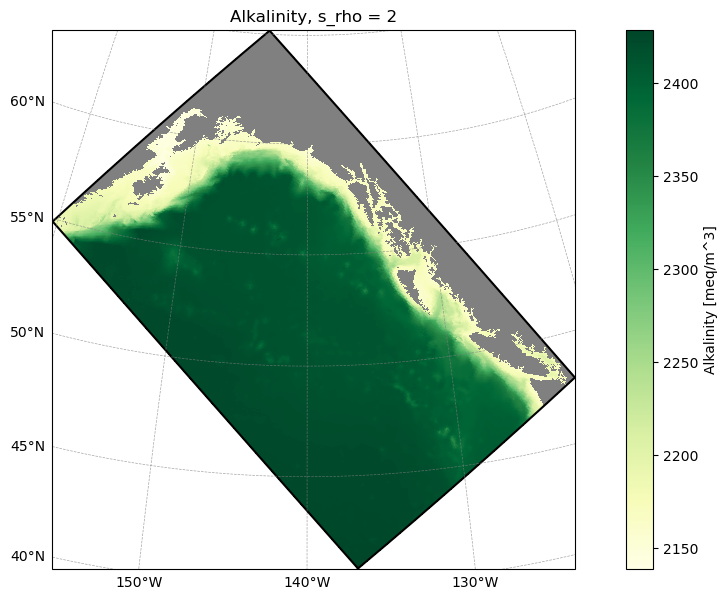

In [8]:
from roms_tools import Grid, ROMSOutput
import pandas as pd
import os

run = "/Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_20100101-20100105"


#grid = Grid.from_file(os.path.join(run,"input","input_datasets","cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_grid.nc"))
roms_output = ROMSOutput(
    grid=ocn.grid,
    path=[ os.path.join(run,'joined_output','output_rst.20100104000000.nc'),
    ])

time_index = pd.DatetimeIndex(roms_output.ds.time.values)
print('First, Last output times: ',time_index[0],time_index[-1])
roms_output.plot("ALK", time=1, s=2)